### ResNet

#### 一、为什么网络不能无限加深
- 当简单堆叠层数时，训练集上的准确率反而下降。这是因为深层网络太难训练，梯度在回传的时候由于乘法效应，要么消失了，要么极其混乱
- 假设20层的网络已经很好了，那么50层的网络理论上至少应该一样好，因为30层只需要学会恒等映射。但由于神经网络是非线性的，让它学什么都不做反而困难

#### 二、残差块
既然模型很难学会恒等映射，就强制给模型捷径
- 传统模型：输入x经过一系列卷积，期望输出H(x)
- ResNet:输出变为F(x)+x
  - 捷径直接将x抄到后面
  - 网络只需要学习输出与输入之间的差值
  - 好比你在考场上做一道大题。ResNet先给基础分（输入x），网络只需要根据自己的理解去不上额外的分（残差F（x））。如果网络觉得这一层没用，直接让权重趋近于0

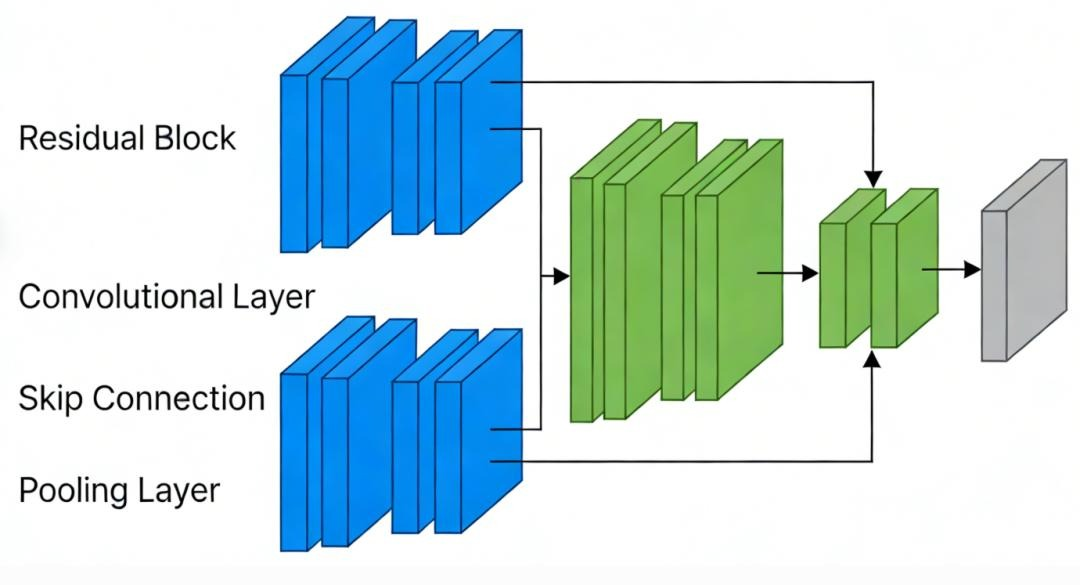

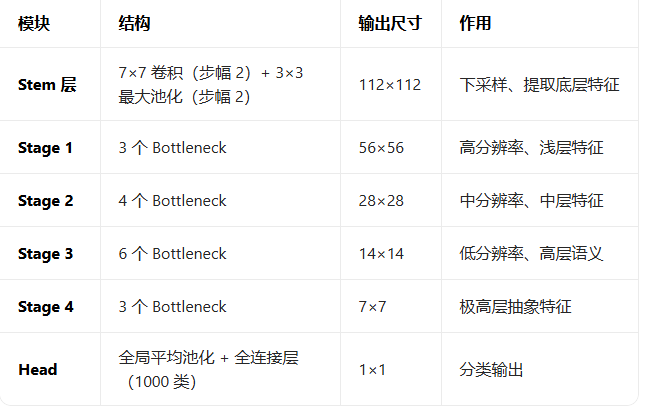

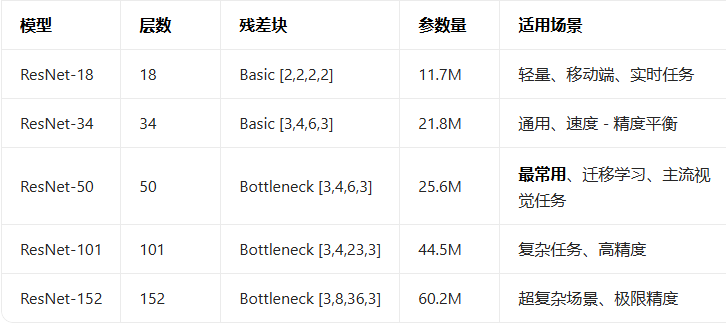

#### 三、关键技术细节
- 批量归一化：所有卷积后立即BN，加速收敛、稳定训练、缓解内部协变量偏移
- 权重初始化：采用He初始化，避免网络过深时梯度消失
- 激活函数：ReLU
- 下采样策略：仅在每个Stage的第一个残差块用步幅2下采样，跳跃连接同步用1x1卷积匹配
- 

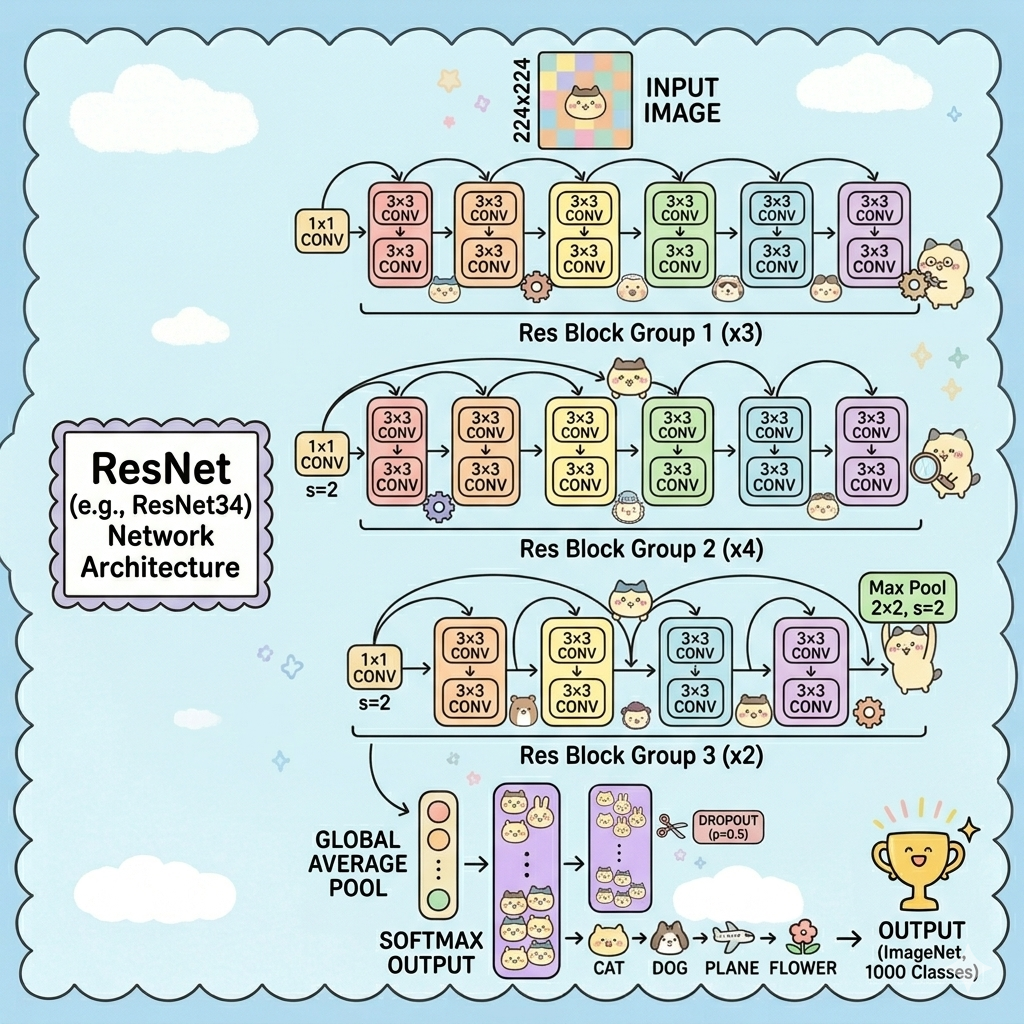

In [1]:
import torch
from torch import nn
from torchsummary import summary


In [6]:
class Residual(nn.Module):
    def __init__(self, input_channels, num_channels, use_1conv=False, strides=1):
        super(Residual, self).__init__()
        self.ReLU = nn.ReLU()
        self.conv1 = nn.Conv2d(in_channels=input_channels, out_channels=num_channels, kernel_size=3, padding=1, stride=strides)
        self.conv2 = nn.Conv2d(in_channels=num_channels,  out_channels=num_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(num_channels)
        self.bn2 = nn.BatchNorm2d(num_channels)
        if use_1conv:
            self.conv3 = nn.Conv2d(in_channels=input_channels, out_channels=num_channels, kernel_size=1, stride=strides)
        else:
            self.conv3 = None
    def forward(self, x):
        y = self.ReLU(self.bn1(self.conv1(x)))
        y = self.bn2(self.conv2(y))
        if self.conv3:
            x = self.conv3(x)
        y = self.ReLU(y+x)
        return y

In [9]:
class ResNet18(nn.Module):
    def __init__(self, Residual):
        super(ResNet18, self).__init__()
        self.b1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=64, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

        self.b2 = nn.Sequential(Residual(64, 64, use_1conv=False, strides=1),
                                Residual(64, 64, use_1conv=False, strides=1))

        self.b3 = nn.Sequential(Residual(64, 128, use_1conv=True, strides=2),
                                Residual(128, 128, use_1conv=False, strides=1))

        self.b4 = nn.Sequential(Residual(128, 256, use_1conv=True, strides=2),
                                Residual(256, 256, use_1conv=False, strides=1))

        self.b5 = nn.Sequential(Residual(256, 512, use_1conv=True, strides=2),
                                Residual(512, 512, use_1conv=False, strides=1))

        self.b6 = nn.Sequential(nn.AdaptiveAvgPool2d((1, 1)),
                                nn.Flatten(),
                                nn.Linear(512, 10))

    def forward(self,x):
      x = self.b1(x)
      x = self.b2(x)
      x = self.b3(x)
      x = self.b4(x)
      x = self.b5(x)
      x = self.b6(x)
      return x
                            

In [10]:
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ResNet18(Residual).to(device)
    print(summary(model, (1, 224, 224)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           3,200
              ReLU-2         [-1, 64, 112, 112]               0
       BatchNorm2d-3         [-1, 64, 112, 112]             128
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,928
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,928
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
         Residual-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,928
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,